# Figure 2. 
Particle trajectories from forward simulations over 1958–1977 in the LENS and FOSI simulations. Black dots mark the 60 particles initialized at 50m within each subtropical gyre: South Pacific (30°–40°S, 220°–240°E) and North Pacific (38°–45°N, 140°–210°E). (a, b) FOSI simulation trajectories for the (a) North and (b) South Pacific. (c, d) As in (a, b), but for LENS. Trajectories in (a)-(d) are colored by depth of the particle at that location and the trajectories in (c, d) show the ensemble member that is most similar to FOSI in each hemisphere, defined as the member with the smallest KDE difference relative to FOSI. (e, f) Difference (FOSI minus LENS) in pathway density over the entire 20-year period for the (e) North and (f) South Pacific. (g, h) As in (c, f), but for the final 5 years only. Contour intervals are 5% (normalized trajectory density) per square degree. Cross-hatching (e)-(h) indicates regions where the PV difference (LENS minus FOSI) exceeds an empirically chosen fraction of the ensemble standard deviation of the PV difference (0.5σ in the North Pacific; 0.1σ in the South Pacific). These thresholds were selected to highlight the regions of observed dynamical barriers and reflect the differing amplitude of PV variability between the two hemispheres. The mean pathway density across LENS ensemble members is used for (e-h).

### Imports

In [1]:
import pop_tools
import xarray as xr
import numpy as np
import cftime
import xesmf as xe
import cmocean
import matplotlib.pyplot as plt
import matplotlib.collections as mcollections
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
from scipy.signal import coherence, csd
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks
from scipy.stats import linregress
import scipy.stats as stats
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import xesmf as xe
import pop_tools
import cftime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import gaussian_kde

import warnings
warnings.filterwarnings('ignore')

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/pop_tools/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
import processing_utils as proc_utils
import cesm2_lens_utils
import analysis_funcs as afuncs
import stc_funcs as stcfuncs

### Functions

In [3]:
def regrid_SMYLE(ds, glat=1, glon=1): # from Jacob's notebook
    """
    Inputs:
        ds: xr.DataArray with coordinates that include TLAT and TLONG
    Returns:
        Regridded xr.DataArray with coordinates lat and lon
    """
    ds = ds.rename(({'ULONG': 'lon', 'ULAT': 'lat'}))
    ds_out = xe.util.grid_global(glon, glat)
    regridder = xe.Regridder(ds, ds_out, 'bilinear', periodic=True)
    regridded = regridder(ds)
    new_coords = regridded.assign_coords({'y': regridded.lat[:, 0].values, 'x': regridded.lon[0].values})
    return new_coords.drop_vars(['lat', 'lon']).rename({'x': 'lon', 'y': 'lat'})

### Set up

In [4]:
# LENS for regridding purposes
CESMLENS_var = afuncs.LENS_for_regridding() # this is Area

#### FOSI set up
firstyear = 1959
lastyear = 2020
grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]

### (a) FOSI: North Pacific

In [8]:
INIT_DEPTH = 50

file_path = '/glade/derecho/scratch/cassiacai/particle_trajectories/particle_trajectories_fosi_NH_startingat{}m_1958_1977.zarr'.format(
    INIT_DEPTH)

fosi_pt = xr.open_zarr(file_path)
f_time, f_lon, f_lat, f_z = stcfuncs.compute_data(fosi_pt)

#### NORTH PACIFIC
da_f, region_idx_f, lon_trunc_f,lat_trunc_f, z_trunc_f = stcfuncs.calc_density(
   lon_data=f_lon, lat_data=f_lat, z_data=f_z, 
    lat_min=38, lat_max=45, 
    lon_min=140, lon_max=210,
    timestart=0, timeend=244)

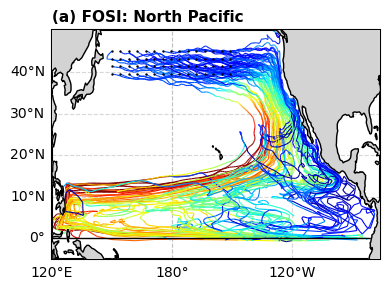

In [9]:
da = da_f
lon_data= lon_trunc_f[:, 0:244]
lat_data= lat_trunc_f[:, 0:244]
z_data= z_trunc_f[:, 0:244]
region_idx = region_idx_f

fig, ax = plt.subplots(figsize=(4, 3),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
# ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
ax.set_extent([120, 284, -5, 50], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
           s=0.5, c='k', marker='o', edgecolor='k', zorder=100,transform=ccrs.PlateCarree())

# contourf_plot = da.plot.contourf(
#     x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
#     levels=11, vmax=60e-5, vmin=0, alpha=1) # 60 for SH

for i in region_idx[::1]:
    lon = lon_data.isel(trajectory=i).values
    lat = lat_data.isel(trajectory=i).values
    depth = z_data.isel(trajectory=i).values
    points = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = mcollections.LineCollection(
            segments, cmap='jet', norm=plt.Normalize(0, 25000), 
            linewidth=0.8, alpha=1, transform=ccrs.PlateCarree())
    lc.set_array(depth[:-1])
    ax.add_collection(lc)

plt.title('(a) FOSI: North Pacific', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.tight_layout()
plt.show()

### (c) LENS: North Pacific

In [5]:
# LENS --- North Pacific
ENS_MEMBERS_LIST = [0, 65,  32, 85, 61, 90, 80, 68, 73, 49] 
INIT_DEPTH = 50

region_indx_list = []; da_list = []
lon_trunc_list = []; lat_trunc_list = []; z_trunc_list = []

for ENS_MEMB in ENS_MEMBERS_LIST:
    print(ENS_MEMB)
    file_path = '/glade/derecho/scratch/cassiacai/particle_trajectories/particle_trajectories_lens{}_NH_startingat{}m_1958_1977.zarr'.format(
        ENS_MEMB, INIT_DEPTH)

    lens_pt = xr.open_zarr(file_path)
    l_time, l_lon, l_lat, l_z = stcfuncs.compute_data(lens_pt)

    ### NORTH PACIFIC
    da_l, region_idx_l,lon_trunc_l,lat_trunc_l, z_trunc_l = stcfuncs.calc_density(
       lon_data=l_lon, lat_data=l_lat, z_data=l_z, 
        lat_min=38, lat_max=45, lon_min=140, lon_max=210,
        timestart=0, timeend=244)
    
    region_indx_list.append(region_idx_l)
    lon_trunc_list.append(lon_trunc_l)
    lat_trunc_list.append(lat_trunc_l)
    z_trunc_list.append(z_trunc_l)
    da_list.append(da_l)

0
65
32
85
61
90
80
68
73
49


In [6]:
da_xr = xr.concat(da_list, dim='ensemble')

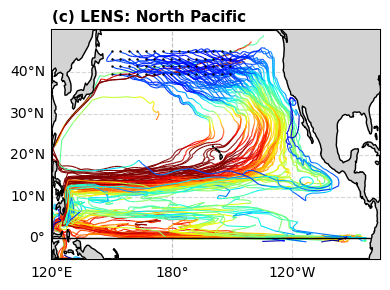

In [7]:
da = da_xr.mean(dim='ensemble')
lon_data= lon_trunc_list[2][ :, 0:244]
lat_data= lat_trunc_list[2][:, 0:244]
z_data= z_trunc_list[2][:, 0:244]
region_idx = region_indx_list[0]

fig, ax = plt.subplots(figsize=(4, 3),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
# ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
ax.set_extent([120, 284, -5, 50], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
           s=0.5, c='k', marker='o', edgecolor='k', zorder=100,transform=ccrs.PlateCarree())

# # #### CONTOURF AND CONTOUR
# contourf_plot = da.plot.contourf(
#     x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
#     levels=11, vmax=60e-5, vmin=0, alpha=1) # 60 for SH

#### TRAJECTORIES
for i in region_indx_list[2][::1]:
    lon = lon_trunc_list[2].isel(trajectory=i).values
    lat = lat_trunc_list[2].isel(trajectory=i).values
    depth = z_trunc_list[2].isel(trajectory=i).values
    points = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = mcollections.LineCollection(
            segments, cmap='jet', norm=plt.Normalize(0, 25000), 
            linewidth=.8, alpha=1, transform=ccrs.PlateCarree())
    lc.set_array(depth[:-1])
    ax.add_collection(lc)

plt.title('(c) LENS: North Pacific', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.tight_layout()
plt.show()

### (e) LENS - FOSI: North Pacific, 0 to 20 years

In [10]:
da_diff_xr = da_f - da_xr
da_diff_xr.mean(dim=('y','x')).argmin()

<xarray.DataArray 'density' ()> Size: 8B
array(3)

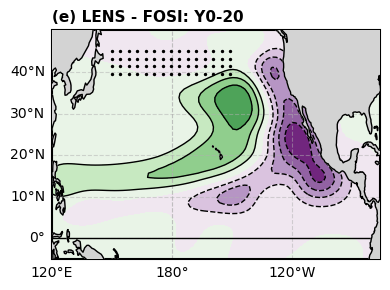

In [11]:
da_diff = da_xr.mean(dim='ensemble') - da_f

fig, ax = plt.subplots(figsize=(4, 3),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -5, 50], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)

ax.scatter(lon_trunc_f[region_idx, 0][::1], lat_trunc_f[region_idx, 0][::1], 
           s=2, c='k', marker='o', edgecolor='k', zorder=200,transform=ccrs.PlateCarree())

# # #### CONTOURF AND CONTOUR
contourf_plot = da_diff.plot.contourf(
    x='lon', y='lat', cmap='PRGn', add_colorbar=False, transform=ccrs.PlateCarree(),
    alpha=1, vmin=-30e-5, vmax=30e-5, levels=13)

# CONTOUR LINES
da_diff.plot.contour(
    x='lon', y='lat', transform=ccrs.PlateCarree(), colors='k', linewidths=1,
    levels=[-20e-5, -15e-5, -10e-5, -5e-5, 5e-5, 10e-5, 15e-5, 20e-5], alpha=1)

plt.title('(e) LENS - FOSI: Y0-20', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.tight_layout()
plt.show()

### (g) LENS - FOSI: North Pacific, last 5 years

In [12]:
# LENS --- North Pacific
ENS_MEMBERS_LIST = [0, 65,  32, 85, 61, 90, 80, 68, 73, 49] 
INIT_DEPTH = 50

region_indx_list = []; da_list = []
lon_trunc_list = []; lat_trunc_list = []; z_trunc_list = []

for ENS_MEMB in ENS_MEMBERS_LIST:
    print(ENS_MEMB)
    file_path = '/glade/derecho/scratch/cassiacai/particle_trajectories/particle_trajectories_lens{}_NH_startingat{}m_1958_1977.zarr'.format(
        ENS_MEMB, INIT_DEPTH)

    lens_pt = xr.open_zarr(file_path)
    l_time, l_lon, l_lat, l_z = stcfuncs.compute_data(lens_pt)

    ### NORTH PACIFIC
    da_l, region_idx_l,lon_trunc_l,lat_trunc_l, z_trunc_l = stcfuncs.calc_density(
       lon_data=l_lon, lat_data=l_lat, z_data=l_z, 
        lat_min=38, lat_max=45, lon_min=140, lon_max=210,
        timestart=244-61, timeend=244)
    
    region_indx_list.append(region_idx_l)
    lon_trunc_list.append(lon_trunc_l)
    lat_trunc_list.append(lat_trunc_l)
    z_trunc_list.append(z_trunc_l)
    da_list.append(da_l)

0
65
32
85
61
90
80
68
73
49


In [13]:
da_xr = xr.concat(da_list, dim='ensemble')

In [14]:
INIT_DEPTH = 50

file_path = '/glade/derecho/scratch/cassiacai/particle_trajectories/particle_trajectories_fosi_NH_startingat{}m_1958_1977.zarr'.format(
    INIT_DEPTH)

fosi_pt = xr.open_zarr(file_path)
f_time, f_lon, f_lat, f_z = stcfuncs.compute_data(fosi_pt)

#### NORTH PACIFIC
da_f, region_idx_f, lon_trunc_f,lat_trunc_f, z_trunc_f = stcfuncs.calc_density(
   lon_data=f_lon, lat_data=f_lat, z_data=f_z, 
    lat_min=38, lat_max=45, 
    lon_min=140, lon_max=210,
    timestart=244-61, timeend=244)

In [17]:
##### ------------  LENS
##### POTENTIAL VORTICITY
time_start = 0; time_end = 240

ENS_MEMBERS_LIST = [0, 65,  32, 85, 61, 90, 80, 68, 73, 49] 

file_paths = [f'/glade/derecho/scratch/cassiacai/regridded_PV_{member}.nc' for member in ENS_MEMBERS_LIST]
LENS_PV_all = xr.open_mfdataset(file_paths, combine='nested', concat_dim='ensemble')
LENS_PV_mean = LENS_PV_all.PV.isel(time=slice(time_start,time_end)).isel(TEMP = 2).mean(dim='time').compute()
LENS_PV_1deg = proc_utils.regrid_SMYLE(LENS_PV_mean)

regridder = xe.Regridder(LENS_PV_1deg, CESMLENS_var[:,:], 'nearest_s2d', periodic=True)

regridded_LENS_PV = np.absolute(regridder(LENS_PV_1deg))

In [18]:
##### ------------  FOSI
##### POTENTIAL VORTICITY
FOSI_PV = xr.open_dataset('/glade/derecho/scratch/cassiacai/regridded_PV_FOSI.nc')
FOSI_PV_mean = FOSI_PV.PV.isel(time=slice(time_start,time_end)).isel(TEMP = 2).mean(dim='time').compute()
FOSI_PV_1deg = proc_utils.regrid_SMYLE(FOSI_PV_mean)
regridded_FOSI_PV = np.absolute(regridder(FOSI_PV_1deg))

In [19]:
diff_PV = regridded_LENS_PV - regridded_FOSI_PV

In [20]:
diff_PV_bin_prog_std = diff_PV.sel(lat=slice(-40, 40), lon=slice(120,290))
diff_PV_bin_prog = diff_PV.mean(dim='ensemble').sel(lat=slice(-40, 40), lon=slice(120,290))
diff_SH_PV_binarize = xr.where(diff_PV_bin_prog > diff_PV_bin_prog_std.std()/10, 1., 0.)
diff_NH_PV_binarize = xr.where(diff_PV_bin_prog > diff_PV_bin_prog_std.std()/2, 1., 0.)

In [21]:
print(diff_PV_bin_prog_std.std()/10)
print(diff_PV_bin_prog_std.std()/2)

<xarray.DataArray ()> Size: 8B
array(2.65970127e-13)
Coordinates:
    TEMP     float64 8B 20.0
Attributes:
    regrid_method:  nearest_s2d
<xarray.DataArray ()> Size: 8B
array(1.32985064e-12)
Coordinates:
    TEMP     float64 8B 20.0
Attributes:
    regrid_method:  nearest_s2d


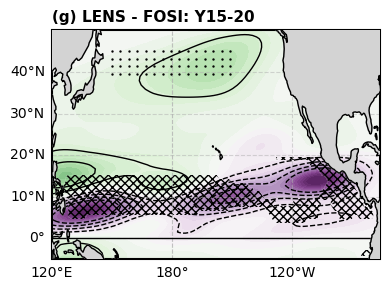

In [22]:
fosi_nan = da_f.fillna(0)
lens_nan = da_xr.mean(dim='ensemble').fillna(0)

diff = lens_nan - fosi_nan

fig, ax = plt.subplots(figsize=(4, 3), 
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -5, 50], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')  # Override the equal aspect ratio

####### DENSITY CONTOUR
contourf_plot = diff.plot.contourf(
    x='lon', y='lat', cmap='PRGn', add_colorbar=False, transform=ccrs.PlateCarree(),
    levels=40, 
    vmax=30e-5, 
    vmin=-30e-5, alpha=1
)

# regridded_LENS_PV.isel(ensemble=ENS_IND).sel(lat=slice(-25, 25), lon=slice(120,290)).plot.contour(cmap='cyan',
#     levels=[0.4e-11, 0.45e-11, 0.5e-11],transform=ccrs.PlateCarree(), add_colorbar=False, zorder=400)

# CONTOUR LINES
diff.plot.contour(
    x='lon', y='lat', transform=ccrs.PlateCarree(), colors='k', linewidths=1,
    levels=[-20e-5, -15e-5, -10e-5, -5e-5, 5e-5, 10e-5, 15e-5, 20e-5], alpha=1)

plt.title('(h)', fontsize=12, fontweight='bold', zorder=12, loc='left')

# diff_PV_binarize.sel(lat=slice(-15, 0), lon=slice(120,240)).plot.contourf(
#     cmap='Grays',transform=ccrs.PlateCarree(), add_colorbar=False, alpha=0.2)
# cs = diff_PV_binarize.sel(lat=slice(-15, 5), lon=slice(120,290)).plot.contourf(
#     transform=ccrs.PlateCarree(), add_colorbar=False, alpha=0.1,
#     hatches=['','xxxx', ''],  # Slanted lines pattern
#     colors='white', levels=[0, 0.5, 1.5]
# )

cs = diff_NH_PV_binarize.sel(lat=slice(-5, 20), lon=slice(120,290)).plot.contourf(
    transform=ccrs.PlateCarree(), add_colorbar=False, alpha=0.15,
    hatches=['','xxxx', ''],
    colors='white', levels=[0, 0.5, 1.5]
)

ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
           s=0.5, c='k', marker='o', edgecolor='k', zorder=100,transform=ccrs.PlateCarree())

plt.title('')
plt.title('(g) LENS - FOSI: Y15-20', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.tight_layout()
plt.show()

### Colorbar

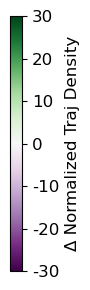

In [24]:
fig, (ax1) = plt.subplots(1, 1, figsize=(1.0, 3))

# Balance colorbar  
density_sm2 = plt.cm.ScalarMappable(cmap='PRGn', norm=plt.Normalize(-30e-5, 30e-5))
cbar2 = plt.colorbar(density_sm2, cax=ax1, orientation='vertical')
cbar2.set_label('Δ Normalized Traj Density', fontsize=12)
tick_values2 = np.arange(-30, 35, 10)  # -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3
cbar2.set_ticks(tick_values2 * 1e-5)
cbar2.set_ticklabels([f'{x:.0f}' for x in tick_values2])
cbar2.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

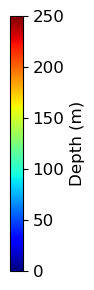

In [25]:
fig, (ax1) = plt.subplots(1, 1, figsize=(1.05, 3))

# Balance colorbar  
density_sm2 = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0, 250))
cbar2 = plt.colorbar(density_sm2, cax=ax1, orientation='vertical')
cbar2.set_label('Depth (m)', fontsize=12)
tick_values2 = np.arange(0, 260, 50)  # -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3
cbar2.set_ticks(tick_values2 * 1)
cbar2.set_ticklabels([f'{x:.0f}' for x in tick_values2])
cbar2.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

### (b) FOSI: South Pacific

In [46]:
INIT_DEPTH = 50

file_path = '/glade/derecho/scratch/cassiacai/particle_trajectories/particle_trajectories_fosi_SH_startingat{}m_1958_1977.zarr'.format(
    INIT_DEPTH)

fosi_pt = xr.open_zarr(file_path)
f_time, f_lon, f_lat, f_z = stcfuncs.compute_data(fosi_pt)

### SOUTH PACIFIC
da_f, region_idx_f,lon_trunc_f,lat_trunc_f, z_trunc_f = stcfuncs.calc_density(
   lon_data=f_lon, lat_data=f_lat, z_data=f_z, 
    lat_min=-40, lat_max=-30, lon_min=215, lon_max=275, # 220 to 240
    timestart=0, timeend=244)
    # timestart=244-61, timeend=244)

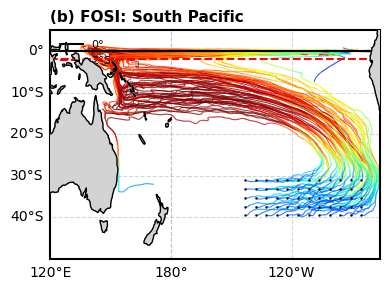

In [32]:
fig, ax = plt.subplots(figsize=(4, 3),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}
gl.ylabel_style = {'size': 10, 'color':'k'}

# Both latitude lines
ax.axhline(y=0,  color='k', linestyle='-',  linewidth=1.5, zorder=6, label='0°')
ax.axhline(y=-2, color='r', linestyle='--', linewidth=1.5, zorder=6, label='2°S')

ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# Initial locations — use raw data
ax.scatter(lon_trunc_f.isel(trajectory=region_idx_f, obs=0),
           lat_trunc_f.isel(trajectory=region_idx_f, obs=0),
           s=0.5, c='k', marker='o', zorder=100, transform=ccrs.PlateCarree())

for i in region_idx_f:
    lon  = lon_trunc_f.isel(trajectory=i).values
    lat  = lat_trunc_f.isel(trajectory=i).values
    dep  = z_trunc_f.isel(trajectory=i).values
    points   = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = mcollections.LineCollection(
        segments, cmap='jet', norm=plt.Normalize(0, 25000),
        linewidth=.8, alpha=0.8, transform=ccrs.PlateCarree())
    lc.set_array(dep[:-1])
    ax.add_collection(lc)

ax.legend(loc='upper left', fontsize=8, frameon=False)
plt.title('(b) FOSI: South Pacific', fontsize=11, fontweight='bold', loc='left')
plt.tight_layout()
plt.show()

### (d) LENS: South Pacific

In [38]:
# LENS --- South Pacific
ENS_MEMBERS_LIST = [0, 65,  32, 85, 61, 90, 80, 68, 73, 49] 
INIT_DEPTH = 50

region_indx_list = []; da_list = []
lon_trunc_list = []; lat_trunc_list = []; z_trunc_list = []

for ENS_MEMB in ENS_MEMBERS_LIST:
    file_path = '/glade/derecho/scratch/cassiacai/particle_trajectories/particle_trajectories_lens{}_SH_startingat{}m_1958_1977.zarr'.format(
        ENS_MEMB, INIT_DEPTH)

    lens_pt = xr.open_zarr(file_path)
    l_time, l_lon, l_lat, l_z = stcfuncs.compute_data(lens_pt)
    print(ENS_MEMB)
    
    ### SOUTH PACIFIC
    da_l, region_idx_l,lon_trunc_l,lat_trunc_l, z_trunc_l = stcfuncs.calc_density(
       lon_data=l_lon, lat_data=l_lat, z_data=l_z, 
        lat_min=-40, lat_max=-30, lon_min=215, lon_max=275,
        timestart=0, timeend=244)
    
    region_indx_list.append(region_idx_l)
    lon_trunc_list.append(lon_trunc_l)
    lat_trunc_list.append(lat_trunc_l)
    z_trunc_list.append(z_trunc_l)
    da_list.append(da_l)

0
65
32
85
61
90
80
68
73
49


In [39]:
da_xr = xr.concat(da_list, dim='ensemble')

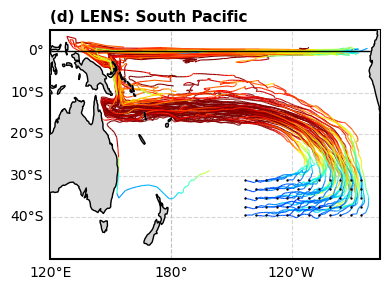

In [40]:
da = da_xr.mean(dim='ensemble')
lon_data= lon_trunc_list[4][ :, 0:244]
lat_data= lat_trunc_list[4][:, 0:244]
z_data= z_trunc_list[4][:, 0:244]
region_idx = region_indx_list[0]

fig, ax = plt.subplots(figsize=(4, 3),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -5, 50], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
           s=0.5, c='k', marker='o', edgecolor='k', zorder=100,transform=ccrs.PlateCarree())

#### TRAJECTORIES
for i in region_indx_list[5][::1]:
    lon = lon_trunc_list[5].isel(trajectory=i).values
    lat = lat_trunc_list[5].isel(trajectory=i).values
    depth = z_trunc_list[5].isel(trajectory=i).values
    points = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = mcollections.LineCollection(
            segments, cmap='jet', norm=plt.Normalize(0, 25000), 
            linewidth=0.8, alpha=1, transform=ccrs.PlateCarree())
    lc.set_array(depth[:-1])
    ax.add_collection(lc)

plt.title('(d) LENS: South Pacific', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.tight_layout()
plt.show()

### (f) LENS - FOSI: South Pacific, 0 to 20 years

In [41]:
da_diff_xr = da_xr - da_f
da_diff_xr.mean(dim=('y','x')).argmin()

<xarray.DataArray 'density' ()> Size: 8B
array(5)

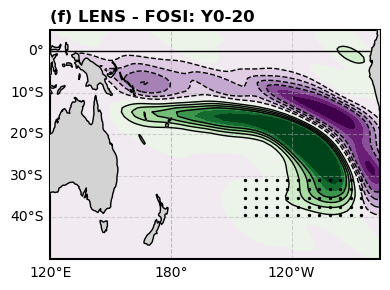

In [47]:
da_diff = da_l - da_f

fig, ax = plt.subplots(figsize=(4, 3), #4, 3
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)

ax.scatter(lon_trunc_f[region_idx, 0][::1], lat_trunc_f[region_idx, 0][::1], 
           s=2, c='k', marker='o', edgecolor='k', zorder=200,transform=ccrs.PlateCarree())

# #### CONTOURF AND CONTOUR
contourf_plot = da_diff.plot.contourf(
    x='lon', y='lat', cmap='PRGn', add_colorbar=False, transform=ccrs.PlateCarree(),
    alpha=1, vmin=-30e-5, vmax=30e-5, levels=13)

# CONTOUR LINES
da_diff.plot.contour(
    x='lon', y='lat', transform=ccrs.PlateCarree(), colors='k', linewidths=1,
    levels=[-20e-5, -15e-5, -10e-5, -5e-5, 5e-5, 10e-5, 15e-5, 20e-5], alpha=1)

plt.title('(f) LENS - FOSI: Y0-20', fontsize=12, fontweight='bold', zorder=12, loc='left')
plt.tight_layout()
plt.show()

### (h) LENS - FOSI: South Pacific, last 5 years

In [48]:
INIT_DEPTH = 50

file_path = '/glade/derecho/scratch/cassiacai/particle_trajectories/particle_trajectories_fosi_SH_startingat{}m_1958_1977.zarr'.format(
    INIT_DEPTH)

fosi_pt = xr.open_zarr(file_path)
f_time, f_lon, f_lat, f_z = stcfuncs.compute_data(fosi_pt)

### SOUTH PACIFIC
da_f, region_idx_f,lon_trunc_f,lat_trunc_f, z_trunc_f = stcfuncs.calc_density(
   lon_data=f_lon, lat_data=f_lat, z_data=f_z, 
    lat_min=-40, lat_max=-30, lon_min=215, lon_max=275, # 220 to 240
    timestart=244-61, timeend=244)

In [49]:
# LENS --- South Pacific
ENS_MEMBERS_LIST = [0, 65,  32, 85, 61, 90, 80, 68, 73, 49] 
INIT_DEPTH = 50

region_indx_list = []; da_list = []
lon_trunc_list = []; lat_trunc_list = []; z_trunc_list = []

for ENS_MEMB in ENS_MEMBERS_LIST:
    file_path = '/glade/derecho/scratch/cassiacai/particle_trajectories/particle_trajectories_lens{}_SH_startingat{}m_1958_1977.zarr'.format(
        ENS_MEMB, INIT_DEPTH)

    lens_pt = xr.open_zarr(file_path)
    l_time, l_lon, l_lat, l_z = stcfuncs.compute_data(lens_pt)
    print(ENS_MEMB)
    
    ### SOUTH PACIFIC
    da_l, region_idx_l,lon_trunc_l,lat_trunc_l, z_trunc_l = stcfuncs.calc_density(
       lon_data=l_lon, lat_data=l_lat, z_data=l_z, 
        lat_min=-40, lat_max=-30, lon_min=215, lon_max=275,
        timestart=244-61, timeend=244)
    
    region_indx_list.append(region_idx_l)
    lon_trunc_list.append(lon_trunc_l)
    lat_trunc_list.append(lat_trunc_l)
    z_trunc_list.append(z_trunc_l)
    da_list.append(da_l)

0
65
32
85
61
90
80
68
73
49


In [52]:
da_xr = xr.concat(da_list, dim='ensemble')
da_diff_xr = da_xr - da_f
da_diff_xr.mean(dim=('y','x')).argmin()

<xarray.DataArray 'density' ()> Size: 8B
array(9)

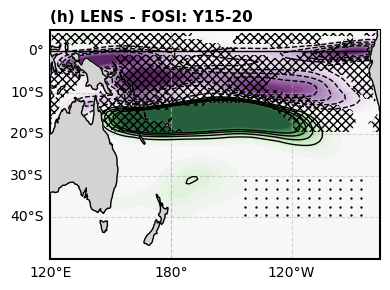

In [53]:
fosi_nan = da_f.fillna(0)
lens_nan = da_xr.mean(dim='ensemble').fillna(0)

diff = lens_nan - fosi_nan

fig, ax = plt.subplots(figsize=(4, 3), 
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')  # Override the equal aspect ratio

####### DENSITY CONTOUR
contourf_plot = diff.plot.contourf(
    x='lon', y='lat', cmap='PRGn', add_colorbar=False, transform=ccrs.PlateCarree(),
    levels=40, 
    vmax=30e-5, 
    vmin=-30e-5, alpha=1
)

# regridded_LENS_PV.isel(ensemble=ENS_IND).sel(lat=slice(-25, 25), lon=slice(120,290)).plot.contour(cmap='cyan',
#     levels=[0.4e-11, 0.45e-11, 0.5e-11],transform=ccrs.PlateCarree(), add_colorbar=False, zorder=400)

# CONTOUR LINES
diff.plot.contour(
    x='lon', y='lat', transform=ccrs.PlateCarree(), colors='k', linewidths=1,
    levels=[-20e-5, -15e-5, -10e-5, -5e-5, 5e-5, 10e-5, 15e-5, 20e-5], alpha=1)

plt.title('(h)', fontsize=12, fontweight='bold', zorder=12, loc='left')

# diff_PV_binarize.sel(lat=slice(-15, 0), lon=slice(120,240)).plot.contourf(
#     cmap='Grays',transform=ccrs.PlateCarree(), add_colorbar=False, alpha=0.2)
# cs = diff_PV_binarize.sel(lat=slice(-15, 5), lon=slice(120,290)).plot.contourf(
#     transform=ccrs.PlateCarree(), add_colorbar=False, alpha=0.1,
#     hatches=['','xxxx', ''],  # Slanted lines pattern
#     colors='white', levels=[0, 0.5, 1.5]
# )

cs = diff_SH_PV_binarize.sel(lat=slice(-20, 5), lon=slice(120,290)).plot.contourf(
    transform=ccrs.PlateCarree(), add_colorbar=False, alpha=0.15,
    hatches=['','xxxx', ''],
    colors='white', levels=[0, 0.5, 1.5]
)

ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
           s=0.5, c='k', marker='o', edgecolor='k', zorder=100,transform=ccrs.PlateCarree())

plt.title('')
plt.title('(h) LENS - FOSI: Y15-20', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.tight_layout()
plt.show()